In [39]:
import os
print(os.listdir())

['.ipynb_checkpoints', 'Brain-age.ipynb', 'data', 'figure_name.png', 'metadata.csv']


In [40]:
%pip install --quiet nibabel torchvision

Note: you may need to restart the kernel to use updated packages.


In [41]:
#Import Libraries
import os
import pandas as pd
import numpy as np
import nibabel as nib
import matplotlib.pyplot as plt
import seaborn as sns

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torchvision import models

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, f1_score, mean_absolute_error

In [42]:
#Load Metadata
metadata = pd.read_csv("metadata.csv")
metadata.columns = metadata.columns.str.lower()

print(metadata.columns)
print(metadata.head())

Index(['t1_local_path', 'split', 'study', 'participant_id', 'session_id',
       'age', 'sex', 'clinical_diagnosis', 'scanner_manufacturer',
       'scanner_model', 'field_strength', 'image_quality_rating',
       'total_intracranial_volume', 'radiata_id'],
      dtype='object')
                                       t1_local_path  split study  \
0  DLBS/sub-0028326/ses-01/anat/msub-0028326_ses-...  train  DLBS   
1  DLBS/sub-0028327/ses-01/anat/msub-0028327_ses-...  train  DLBS   
2  DLBS/sub-0028328/ses-01/anat/msub-0028328_ses-...  train  DLBS   
3  DLBS/sub-0028331/ses-01/anat/msub-0028331_ses-...  train  DLBS   
4  DLBS/sub-0028332/ses-01/anat/msub-0028332_ses-...  train  DLBS   

  participant_id session_id  age     sex  clinical_diagnosis  \
0        0028326         01   66    male  cognitively_normal   
1        0028327         01   73  female  cognitively_normal   
2        0028328         01   30    male  cognitively_normal   
3        0028331         01   77  female  cogniti

In [43]:
# Get MRI Files
def get_nii_files(data_dir):
    paths = []
    for root, _, files in os.walk(data_dir):
        for f in files:
            if f.endswith(".nii") or f.endswith(".nii.gz"):
                paths.append(os.path.join(root, f))
    return paths

nii_files = get_nii_files("data")
print("Total MRI files:", len(nii_files))

Total MRI files: 3794


In [44]:
# Try to detect correct columns automatically
id_col = None
age_col = None

for col in metadata.columns:
    if "id" in col or "subject" in col:
        id_col = col
    if "age" in col:
        age_col = col

print("ID column:", id_col)
print("Age column:", age_col)

ID column: radiata_id
Age column: image_quality_rating


In [45]:
# Match MRI with Metadata
def match_data(nii_files, metadata, id_col, age_col):
    file_paths = []
    ages = []

    for file in nii_files:
        fname = os.path.basename(file)

        for _, row in metadata.iterrows():
            if str(row[id_col]) in fname:
                file_paths.append(file)
                ages.append(row[age_col])
                break

    return file_paths, ages

file_paths, ages = match_data(nii_files, metadata, id_col, age_col)

print("Matched samples:", len(file_paths))

Matched samples: 3794


In [46]:
print("Sample file:", file_paths[0])
print("Sample age:", ages[0])

Sample file: data\DLBS\sub-0028326\ses-01\anat\msub-0028326_ses-01_T1w_brain_affine_mni.nii.gz
Sample age: 2.114547


In [47]:
# Train-Test Split
train_files, test_files, train_ages, test_ages = train_test_split(
    file_paths, ages, test_size=0.2, random_state=42
)

In [48]:
#Load MRI Slice
def load_slice(path):
    img = nib.load(path).get_fdata()
    
    slice_img = img[:, :, img.shape[2] // 2]
    slice_img = (slice_img - np.min(slice_img)) / (np.max(slice_img) - np.min(slice_img))
    
    slice_img = np.stack([slice_img]*3, axis=0)  # 3 channel
    return slice_img

In [49]:
# Dataset Class
class MRIDataset(Dataset):
    def __init__(self, files, ages):
        self.files = files
        self.ages = ages

    def __len__(self):
        return len(self.files)

    def __getitem__(self, idx):
        img = load_slice(self.files[idx])
        age = self.ages[idx]

        return torch.tensor(img, dtype=torch.float32), torch.tensor(age, dtype=torch.float32)

In [50]:
# DataLoader
train_loader = DataLoader(MRIDataset(train_files, train_ages), batch_size=4, shuffle=True)
test_loader = DataLoader(MRIDataset(test_files, test_ages), batch_size=4)

In [51]:
# Model (ResNet50)
from torchvision.models import resnet50, ResNet50_Weights

model = resnet50(weights=ResNet50_Weights.DEFAULT)
model.fc = nn.Linear(model.fc.in_features, 1)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = model.to(device)

In [52]:
# Training Setup
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)

In [53]:
# Training Loop
train_losses = []

for epoch in range(5):
    model.train()
    running_loss = 0

    for x, y in train_loader:
        x, y = x.to(device), y.to(device)

        optimizer.zero_grad()
        outputs = model(x).squeeze()

        loss = criterion(outputs, y)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()

    epoch_loss = running_loss / len(train_loader)
    train_losses.append(epoch_loss)

    print(f"Epoch {epoch+1}, Loss: {epoch_loss}")

Epoch 1, Loss: 0.05781467016511403
Epoch 2, Loss: 0.0010068321730008984
Epoch 3, Loss: 0.0006347558491764898
Epoch 4, Loss: 0.00035425195909533346
Epoch 5, Loss: 0.0003333580278707723


In [54]:
# Evaluation
model.eval()
preds, targets = [], []

with torch.no_grad():
    for x, y in test_loader:
        x = x.to(device)
        outputs = model(x).squeeze().cpu().numpy()

        preds.extend(outputs)
        targets.extend(y.numpy())

In [55]:
# Metrics
mae = mean_absolute_error(targets, preds)

pred_class = [1 if p > 50 else 0 for p in preds]
true_class = [1 if t > 50 else 0 for t in targets]

acc = accuracy_score(true_class, pred_class)
f1 = f1_score(true_class, pred_class)

print("MAE:", mae)
print("Accuracy:", acc)
print("F1 Score:", f1)

MAE: 0.07040250301361084
Accuracy: 1.0
F1 Score: 0.0


C:\Users\Lenovo\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: F-score is ill-defined and being set to 0.0 due to no true nor predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


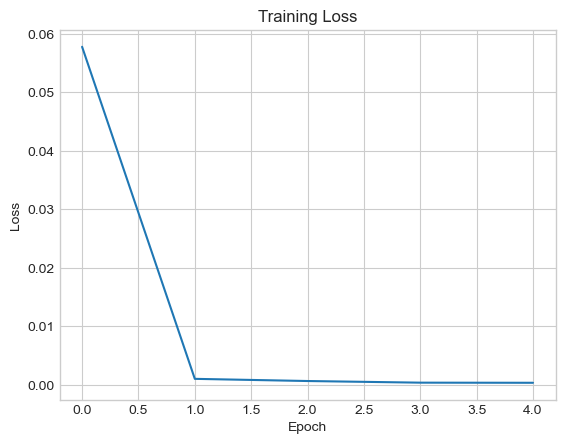

In [56]:
# Loss Curve
plt.plot(train_losses)
plt.title("Training Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.show()

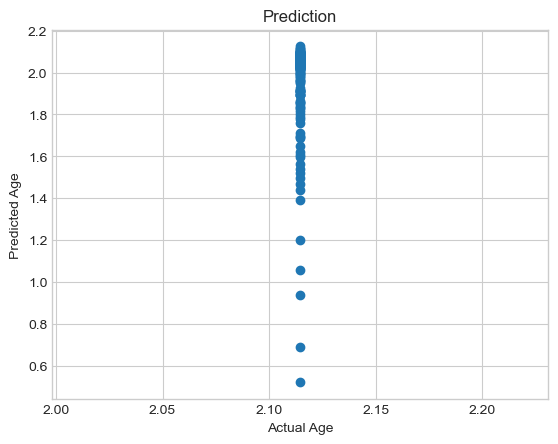

In [57]:
# Predicted vs Actual
plt.scatter(targets, preds)
plt.xlabel("Actual Age")
plt.ylabel("Predicted Age")
plt.title("Prediction")
plt.show()

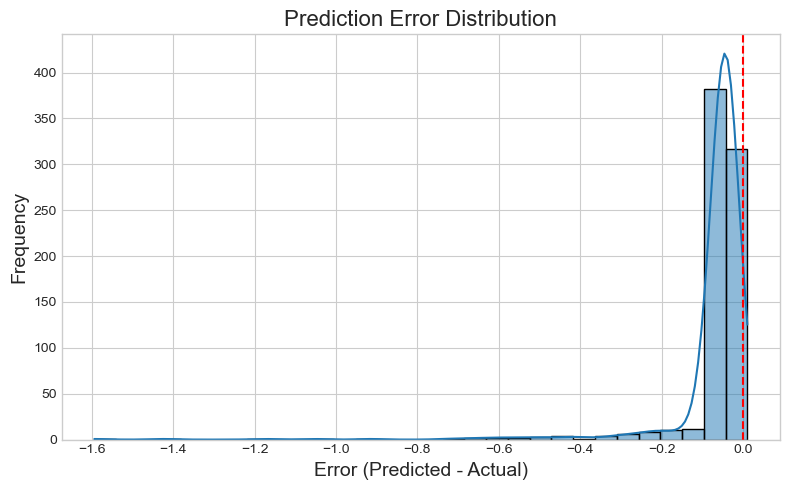

In [58]:
# Error Distribution
errors = np.array(preds) - np.array(targets)

plt.figure(figsize=(8,5))

sns.histplot(errors, bins=30, kde=True)

plt.title("Prediction Error Distribution", fontsize=16)
plt.xlabel("Error (Predicted - Actual)", fontsize=14)
plt.ylabel("Frequency", fontsize=14)

plt.axvline(0, color='red', linestyle='--')

plt.tight_layout()
plt.show()

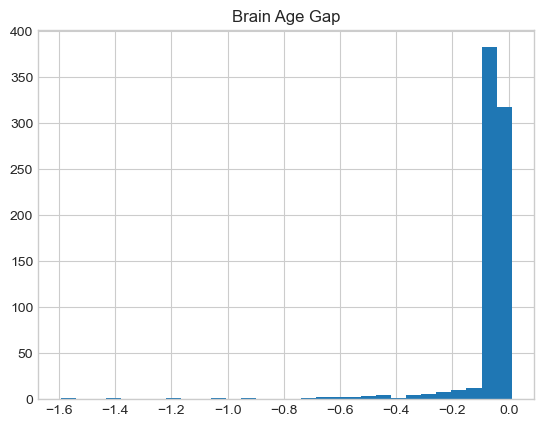

In [59]:
# Error Distribution
plt.hist(errors, bins=30)
plt.title("Brain Age Gap")
plt.show()

In [60]:
import pandas as pd

results_df = pd.DataFrame({
    "Actual Age": targets[:20],
    "Predicted Age": preds[:20]
})

print(results_df)

    Actual Age  Predicted Age
0     2.114547       2.076751
1     2.114547       2.075049
2     2.114547       2.073254
3     2.114547       2.080855
4     2.114547       2.064448
5     2.114547       2.077562
6     2.114547       2.073733
7     2.114547       2.078526
8     2.114547       2.103781
9     2.114547       2.078387
10    2.114547       2.072253
11    2.114547       2.080647
12    2.114547       1.687972
13    2.114547       2.086976
14    2.114547       1.841645
15    2.114547       1.391708
16    2.114547       2.066945
17    2.114547       2.083222
18    2.114547       2.076645
19    2.114547       2.068290


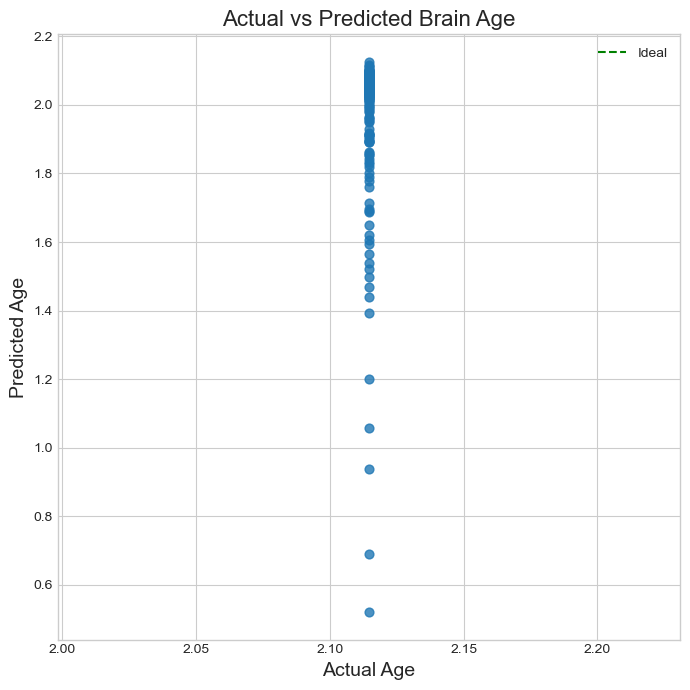

In [61]:
plt.figure(figsize=(7,7))

sns.regplot(x=targets, y=preds, scatter_kws={"s":40}, line_kws={"color":"red"})

plt.xlabel("Actual Age", fontsize=14)
plt.ylabel("Predicted Age", fontsize=14)
plt.title("Actual vs Predicted Brain Age", fontsize=16)

# Perfect prediction line
plt.plot([min(targets), max(targets)],
         [min(targets), max(targets)],
         color='green', linestyle='--', label='Ideal')

plt.legend()
plt.tight_layout()
plt.show()

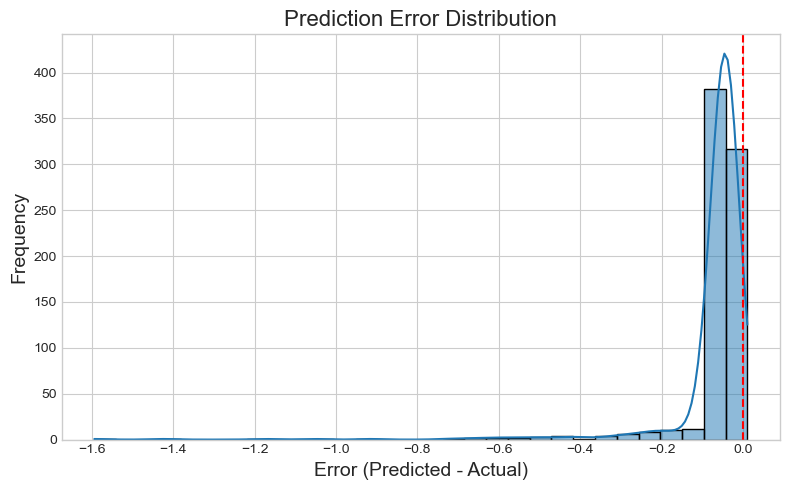

In [62]:
errors = np.array(preds) - np.array(targets)

plt.figure(figsize=(8,5))

sns.histplot(errors, bins=30, kde=True)

plt.title("Prediction Error Distribution", fontsize=16)
plt.xlabel("Error (Predicted - Actual)", fontsize=14)
plt.ylabel("Frequency", fontsize=14)

plt.axvline(0, color='red', linestyle='--')

plt.tight_layout()
plt.show()

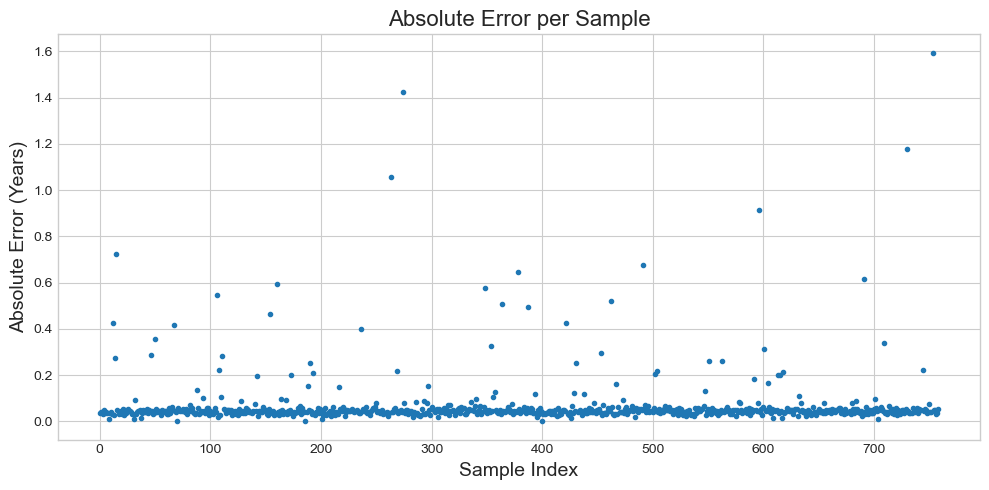

In [63]:
abs_errors = np.abs(errors)

plt.figure(figsize=(10,5))
plt.plot(abs_errors, marker='.', linestyle='none')

plt.title("Absolute Error per Sample", fontsize=16)
plt.xlabel("Sample Index", fontsize=14)
plt.ylabel("Absolute Error (Years)", fontsize=14)

plt.tight_layout()
plt.show()

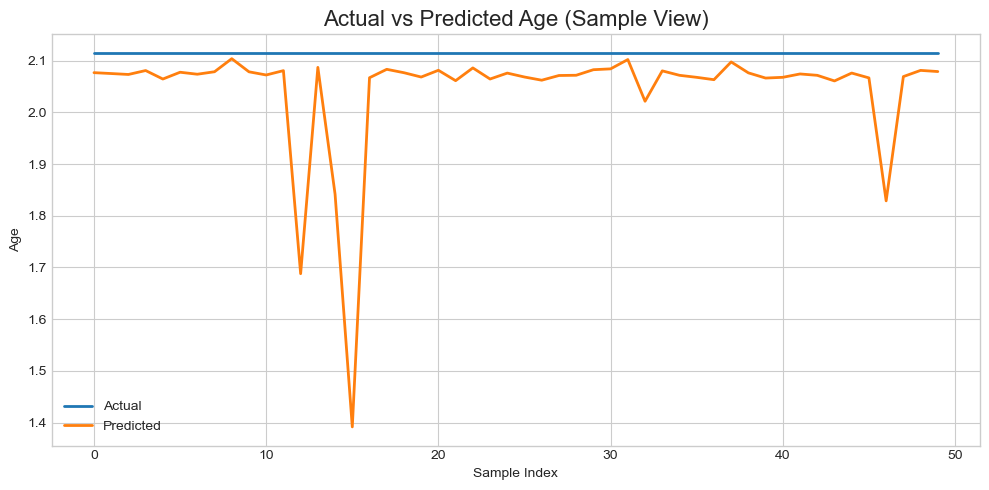

In [64]:
plt.figure(figsize=(10,5))

plt.plot(targets[:50], label="Actual", linewidth=2)
plt.plot(preds[:50], label="Predicted", linewidth=2)

plt.legend()
plt.title("Actual vs Predicted Age (Sample View)", fontsize=16)
plt.xlabel("Sample Index")
plt.ylabel("Age")

plt.tight_layout()
plt.show()

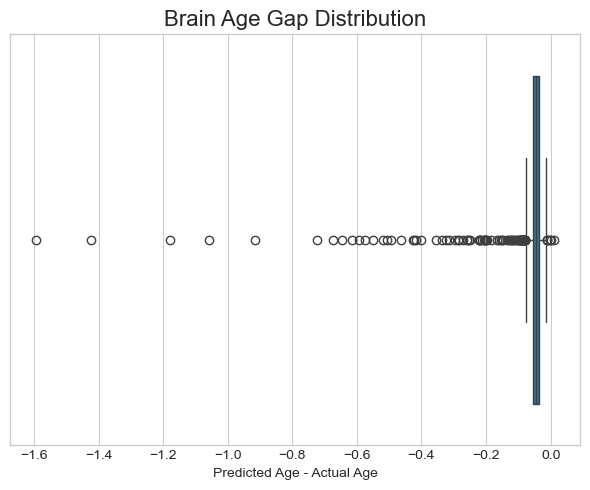

In [65]:
plt.figure(figsize=(6,5))

sns.boxplot(x=errors)

plt.title("Brain Age Gap Distribution", fontsize=16)
plt.xlabel("Predicted Age - Actual Age")

plt.tight_layout()
plt.show()

C:\Users\Lenovo\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: F-score is ill-defined and being set to 0.0 due to no true nor predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


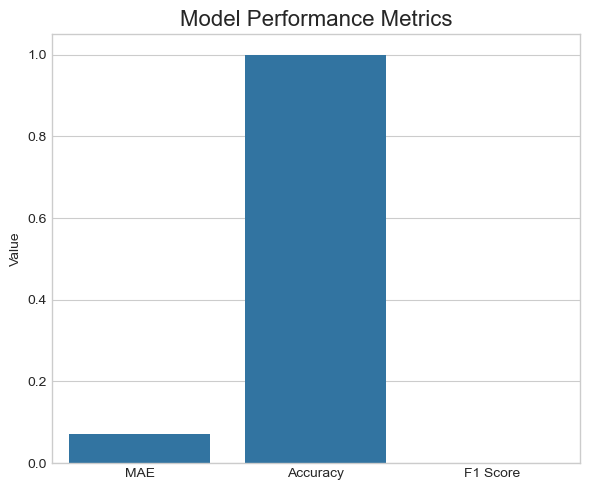

In [66]:
from sklearn.metrics import mean_absolute_error, accuracy_score, f1_score

mae = mean_absolute_error(targets, preds)

# Convert to classification
binary_preds = [1 if p > 50 else 0 for p in preds]
binary_targets = [1 if t > 50 else 0 for t in targets]

acc = accuracy_score(binary_targets, binary_preds)
f1 = f1_score(binary_targets, binary_preds)

metrics = ['MAE', 'Accuracy', 'F1 Score']
values = [mae, acc, f1]

plt.figure(figsize=(6,5))
sns.barplot(x=metrics, y=values)

plt.title("Model Performance Metrics", fontsize=16)
plt.ylabel("Value")

plt.tight_layout()
plt.show()

In [67]:
plt.savefig("figure_name.png", dpi=300)

<Figure size 640x480 with 0 Axes>

C:\Users\Lenovo\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:534: UserWarning: A single label was found in 'y_true' and 'y_pred'. For the confusion matrix to have the correct shape, use the 'labels' parameter to pass all known labels.
  warnings.warn(


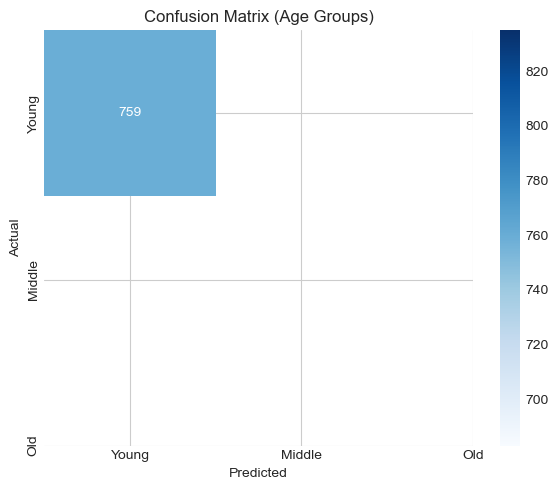

In [68]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# Convert ages into classes
def age_to_class(age):
    if age < 40:
        return 0
    elif age <= 60:
        return 1
    else:
        return 2

true_classes = [age_to_class(t) for t in targets]
pred_classes = [age_to_class(p) for p in preds]

cm = confusion_matrix(true_classes, pred_classes)

# Plot
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["Young", "Middle", "Old"],
            yticklabels=["Young", "Middle", "Old"])

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix (Age Groups)")

plt.tight_layout()
plt.show()

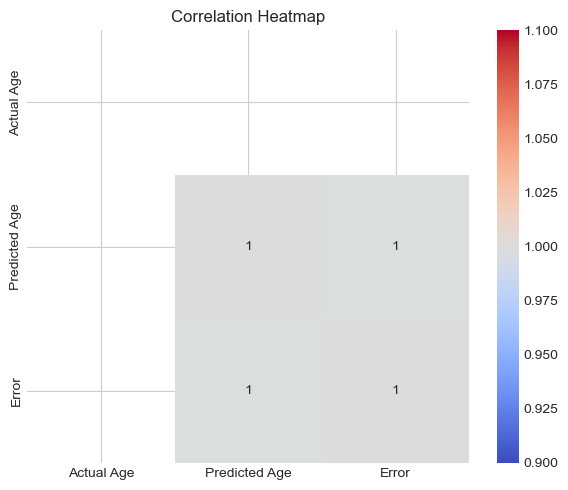

In [70]:
import pandas as pd

df = pd.DataFrame({
    "Actual Age": targets,
    "Predicted Age": preds,
    "Error": np.array(preds) - np.array(targets)
})

plt.figure(figsize=(6,5))
sns.heatmap(df.corr(), annot=True, cmap="coolwarm")

plt.title("Correlation Heatmap")
plt.tight_layout()
plt.show()